# Caculate (Cricket)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [20]:
class BatsmanState(TypedDict):

    Runs : int
    Balls : int
    Fours : int
    Sixes : int

# calculate 
    Strike_Rate: float
    Ball_per_Boundary: float
    Boundary_per: float
    Summary: str

In [ ]:
def calculate_SR(state:BatsmanState): # -> BatsmanState don't show becouse retutn change as a only one not the complate state
    Strike_Rate= (state['Runs'] / state['Balls']) * 100
    return {'Strike_Rate':Strike_Rate} # 

In [22]:
def calculate_BPB(state: BatsmanState):
   Ball_per_Boundary= state['Balls'] / (state['Fours'] + state['Sixes'])
   return {'Ball_per_Boundary':Ball_per_Boundary}

In [23]:
def calculate_BP(state: BatsmanState):
    Boundary_per= ((state['Fours'] + state['Sixes']) / state['Balls']) * 100
    return {'Boundary_per':Boundary_per}

In [24]:
def Summary(state: BatsmanState):
    state['Summary'] = f"""
Strike Rate - {state['Strike_Rate']:.2f}
Balls per boundary - {state['Ball_per_Boundary']:.2f}
Boundary percent - {state['Boundary_per']:.2f}
"""
    return state

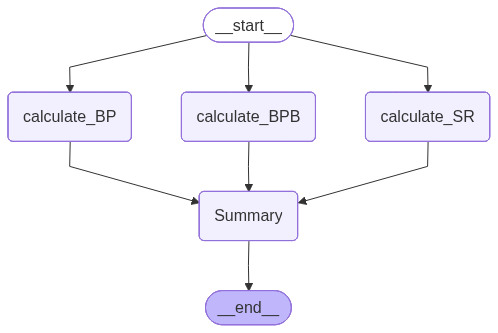

In [25]:
graph = StateGraph(BatsmanState)

# add Nodes:
graph.add_node('calculate_SR', calculate_SR)
graph.add_node('calculate_BPB', calculate_BPB)
graph.add_node('calculate_BP', calculate_BP)
graph.add_node('Summary', Summary)

# add edges
graph.add_edge(START, 'calculate_SR')
graph.add_edge(START, 'calculate_BPB')
graph.add_edge(START, 'calculate_BP')

# add Combine
graph.add_edge('calculate_SR', 'Summary')
graph.add_edge('calculate_BPB', 'Summary')
graph.add_edge('calculate_BP', 'Summary')

graph.add_edge('Summary', END)

workflow = graph.compile()
workflow

In [26]:

initial_state = {
    'Runs': 100,
    'Balls': 50,
    'Fours': 2,
    'Sixes': 2,
}
workflow.invoke(initial_state)

{'Runs': 100,
 'Balls': 50,
 'Fours': 2,
 'Sixes': 2,
 'Strike_Rate': 200.0,
 'Ball_per_Boundary': 12.5,
 'Boundary_per': 8.0,
 'Summary': '\nStrike Rate - 200.00\nBalls per boundary - 12.50\nBoundary percent - 8.00\n'}